In [1]:
# !pip install folium osmnx geopandas pandas shapely

import folium
import osmnx as ox
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
from datetime import datetime

In [2]:
### CONSTS ###
TRAFFIC_DIR = "../data/traffic"

LAT = 48.14553552490184
LNG = 17.114780288953938
RADIUS = 3000  # meters

MAP_ZOOM = 14
MAP_WIDTH = 2304
MAP_HEIGHT = 2304

START_TIME = datetime(2025, 1, 31, 6, 0)
END_TIME = datetime(2025, 1, 31, 9, 30)

# Load data into traffic graph

In [3]:
from city_graph import build_road_graph, visualize_graph

G_major, nodes_major, edges_major = build_road_graph("Bratislava, Slovakia")

m = visualize_graph(nodes_major, edges_major)
m

Loaded cached traffic raster



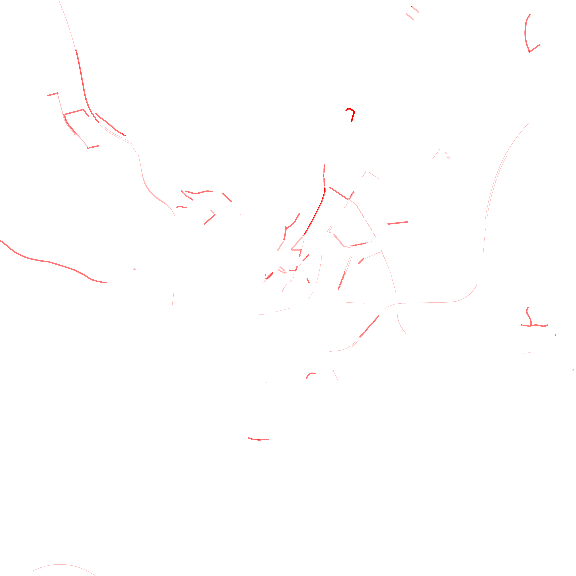

In [4]:
from traffic_data import build_traffic_raster, visualize_traffic_raster

aggregated_image = build_traffic_raster(
    folder=TRAFFIC_DIR, start_time=START_TIME, end_time=END_TIME, step=4
)

traffic_map = visualize_traffic_raster(
    raster=aggregated_image,
    center_lat=48.14553552490184,
    center_lng=17.114780288953938,
    zoom=14,
    width=2304,
    height=2304,
)
traffic_map

In [5]:
from traffic_graph import add_congestion_to_graph, visualize_weighted_graph


G_weighted = add_congestion_to_graph(
    graph=G_major,
    raster_image=aggregated_image,
    center_lat=LAT,
    center_lng=LNG,
    zoom=MAP_ZOOM,
)
print(G_weighted)

map_congestion = visualize_weighted_graph(G_weighted, center_lat=LAT, center_lng=LNG)
map_congestion

MultiDiGraph with 1961 nodes and 2935 edges


In [6]:
from vehicle_data import load_vehicle_positions, vehicle_heatmap

vehicles = load_vehicle_positions("../data/vehicles/merged_vehicles_piatok.csv", START_TIME, END_TIME)
vehicles.head()
         
m = vehicle_heatmap(vehicles, center_lat=LAT, center_lng=LNG)
m

In [7]:
from filter import crop_graph_radius

G_center = crop_graph_radius(
    G_weighted, center_lat=LAT, center_lng=LNG, radius_m=RADIUS
)

map = visualize_weighted_graph(G_center, center_lat=48.1486, center_lng=17.1077)
map

# Deployments

In [ ]:
from rsu.static_deployment import deploy_static_rsus
from rsu.visualize import visualize_rsu_deployment

NUM_RSUS = 10
COVERAGE_RADIUS = 300  # meters (urban DSRC approx)

rsu_nodes_static = deploy_static_rsus(
    graph=G_center, num_rsus=NUM_RSUS, coverage_radius_m=COVERAGE_RADIUS
)
print(rsu_nodes_static)

m = visualize_rsu_deployment(
    graph=G_center,
    rsu_nodes=rsu_nodes_static,
    center_lat=LAT,
    center_lng=LNG
)
m

In [ ]:
from rsu.cluster_deployment import deploy_cluster_head_rsus

rsu_nodes_cluster = deploy_cluster_head_rsus(G_center, num_rsus=10)

m = visualize_rsu_deployment(
    graph=G_center, rsu_nodes=rsu_nodes_cluster, center_lat=LAT, center_lng=LNG
)
m

In [ ]:
from rsu.hybrid_deployment import hybrid_rsu_deployment
from rsu.visualize import visualize_hybrid_deployment

S_static, M_mobile = hybrid_rsu_deployment(
    G_center, vehicles, total_rsu_budget=20, srsu_radius=300, mrsu_radius=400
)

rsu_nodes_hybrid = S_static + M_mobile

m = visualize_hybrid_deployment(
    G=G_center, rsu_nodes=S_static, vehicles_df=vehicles, center_lat=LAT, center_lng=LNG, vehicle_radius=300
)
m

# Evaluation

In [9]:
from evaluation import build_comparison_table, plot_coverage, run_experiment
from rsu.hybrid_deployment import hybrid_rsu_deployment
from rsu.cluster_deployment import deploy_cluster_head_rsus
from rsu.static_deployment import deploy_static_rsus

strategies = {
    "cluster": deploy_cluster_head_rsus,
    "traffic": deploy_static_rsus,
    "hybrid": hybrid_rsu_deployment,
}

budgets = range(5, 101, 5)

df = df = run_experiment(
    G_center, vehicles, strategies, budgets, r_static=300, r_mobile=450
)


=== Running strategy: cluster ===
[1/60] Budget=5
   graph_cov=0.076, traffic_cov=0.095, static=5, mobile=0
[2/60] Budget=10
   graph_cov=0.157, traffic_cov=0.221, static=10, mobile=0
[3/60] Budget=15
   graph_cov=0.294, traffic_cov=0.393, static=15, mobile=0
[4/60] Budget=20
   graph_cov=0.456, traffic_cov=0.552, static=20, mobile=0
[5/60] Budget=25
   graph_cov=0.527, traffic_cov=0.597, static=25, mobile=0
[6/60] Budget=30
   graph_cov=0.623, traffic_cov=0.608, static=30, mobile=0
[7/60] Budget=35
   graph_cov=0.666, traffic_cov=0.631, static=35, mobile=0
[8/60] Budget=40
   graph_cov=0.747, traffic_cov=0.716, static=40, mobile=0
[9/60] Budget=45
   graph_cov=0.794, traffic_cov=0.818, static=45, mobile=0
[10/60] Budget=50
   graph_cov=0.819, traffic_cov=0.832, static=50, mobile=0
[11/60] Budget=55
   graph_cov=0.896, traffic_cov=0.933, static=55, mobile=0
[12/60] Budget=60
   graph_cov=0.903, traffic_cov=0.939, static=60, mobile=0
[13/60] Budget=65
   graph_cov=0.922, traffic_cov=0.

In [11]:
import pandas as pd

df = pd.read_csv("csv/rsu_experiment_results.csv")

# pivot to wide format
table = df.pivot_table(
    index="budget",
    columns="strategy",
    values=["traffic_coverage", "graph_coverage"],
)

# flatten column names
table.columns = [f"{metric}_{strategy}" for metric, strategy in table.columns]

# convert to percentages
table = table * 100

# round values
table = table.round(1)

# desired column order
column_order = [
    "traffic_coverage_cluster",
    "traffic_coverage_traffic",
    "traffic_coverage_hybrid",
    "graph_coverage_cluster",
    "graph_coverage_traffic",
    "graph_coverage_hybrid",
]

# keep only columns that exist
column_order = [c for c in column_order if c in table.columns]

table = table[column_order]

# sort rows by RSU budget
table = table.sort_index()

latex = table.to_latex(
    index=True,
    caption="Coverage comparison of RSU deployment strategies (\\%).",
    label="tab:coverage_results",
    float_format="%.1f",
)

print(latex)

\begin{table}
\caption{Coverage comparison of RSU deployment strategies (\%).}
\label{tab:coverage_results}
\begin{tabular}{lrrrrrr}
\toprule
 & traffic_coverage_cluster & traffic_coverage_traffic & traffic_coverage_hybrid & graph_coverage_cluster & graph_coverage_traffic & graph_coverage_hybrid \\
budget &  &  &  &  &  &  \\
\midrule
5 & 9.5 & 48.0 & 40.2 & 7.6 & 14.6 & 26.1 \\
10 & 22.1 & 72.4 & 65.9 & 15.7 & 26.7 & 44.5 \\
15 & 39.3 & 85.0 & 76.7 & 29.4 & 34.2 & 58.2 \\
20 & 55.2 & 91.8 & 81.5 & 45.6 & 42.5 & 68.4 \\
25 & 59.7 & 96.5 & 86.8 & 52.7 & 48.6 & 78.2 \\
30 & 60.8 & 98.6 & 87.6 & 62.3 & 52.3 & 86.3 \\
35 & 63.1 & 99.9 & 93.9 & 66.6 & 56.7 & 91.2 \\
40 & 71.6 & 100.0 & 96.1 & 74.7 & 59.4 & 95.3 \\
45 & 81.8 & 100.0 & 97.4 & 79.4 & 59.8 & 97.4 \\
50 & 83.2 & 100.0 & 98.5 & 81.9 & 59.8 & 98.3 \\
55 & 93.3 & 100.0 & 98.5 & 89.6 & 61.0 & 99.0 \\
60 & 93.9 & 100.0 & 98.5 & 90.3 & 63.0 & 99.4 \\
65 & 93.8 & 100.0 & 100.0 & 92.2 & 63.1 & 99.8 \\
70 & 96.2 & 100.0 & 100.0 & 93.3 & 

In [12]:
import pandas as pd


df = pd.read_csv("csv/rsu_experiment_results.csv")

# keep only hybrid rows
hybrid = df[df["strategy"] == "hybrid"]

# select budgets of interest
hybrid = hybrid[hybrid["budget"].isin([5, 10, 20, 40, 60, 75, 100])]

# compute guaranteed coverage %
hybrid["guaranteed_ratio_pct"] = (hybrid["guaranteed_ratio"] * 100).round(1)

# start latex table
latex = r"""\begin{table}[t]
\centering
\begin{tabular}{c|cc|c}
\hline
& \multicolumn{2}{c|}{\textbf{Hybrid RSUs}} 
& \textbf{Guaranteed Coverage} \\
\textbf{Total RSUs} & Static & Mobile & Static Share (\%) \\
\hline
"""

for _, row in hybrid.iterrows():

    latex += f"{int(row['budget'])} & {int(row['static_rsus'])} & {int(row['mobile_rsus'])} & {row['guaranteed_ratio_pct']} \\\\\n"

latex += r"""\hline
\end{tabular}
\caption{Infrastructure composition of the hybrid RSU deployment strategy.}
\label{tab:hybrid_composition}
\end{table}
"""

print(latex)

\begin{table}[t]
\centering
\begin{tabular}{c|cc|c}
\hline
& \multicolumn{2}{c|}{\textbf{Hybrid RSUs}} 
& \textbf{Guaranteed Coverage} \\
\textbf{Total RSUs} & Static & Mobile & Static Share (\%) \\
\hline
5 & 2 & 3 & 30.9 \\
10 & 3 & 7 & 24.0 \\
20 & 6 & 14 & 24.6 \\
40 & 12 & 28 & 25.8 \\
60 & 18 & 42 & 31.8 \\
75 & 22 & 50 & 35.9 \\
100 & 22 & 50 & 35.9 \\
\hline
\end{tabular}
\caption{Infrastructure composition of the hybrid RSU deployment strategy.}
\label{tab:hybrid_composition}
\end{table}



# Figures

In [ ]:
from figures import _save_map_png

m = visualize_weighted_graph(G_weighted, center_lat=LAT, center_lng=LNG)
folium.Circle(
    location=[LAT, LNG], radius=RADIUS*10, color="yellow", fill=False, weight=2
).add_to(m)
_save_map_png(m, "img/figure_traffic_graph.png")

m = visualize_hybrid_deployment(
    G=G_weighted,
    rsu_nodes=[],
    vehicles_df=vehicles,
    center_lat=LAT,
    center_lng=LNG,
    vehicle_radius=300,
)
folium.Circle(
    location=[LAT, LNG], radius=RADIUS * 10, color="yellow", fill=False, weight=2
).add_to(m)
_save_map_png(m, "img/figure_vehicles_graph.png")

In [17]:
from figures import _save_map_png


m = visualize_hybrid_deployment(
    G=G_center,
    rsu_nodes=S_static,
    vehicles_df=vehicles,
    center_lat=LAT,
    center_lng=LNG,
    vehicle_radius=300,
)
_save_map_png(m, "img/figure_hybrid_deployment.png")

Saved img/figure_hybrid_deployment.png


In [ ]:
from evaluation import plot_combined_coverage, plot_coverage_curves_seaborn, plot_graph_coverage_seaborn, plot_guaranteed_ratio, plot_hybrid_allocation
import pandas as pd

df = pd.read_csv("csv/rsu_experiment_results.csv")

plot_coverage_curves_seaborn(df)
plot_graph_coverage_seaborn(df)
plot_hybrid_allocation(df)
plot_guaranteed_ratio(df) 

plot_combined_coverage(df, save_path="img/coverage_curves.png")